# 03 · Non-covalent binding modes

For a multi-fragment complex, rxembed **discovers the cooperative binding modes** — combinations of contacts that grip a partner together — and conf-searches each. Multipoint binding (not any single weak contact) is what stabilises these complexes, so a *mode* is a whole grip. Beyond H-bonds: halogen and chalcogen σ-holes, and charge-assisted salt bridges.

In [1]:
import tempfile

import rxembed as rx
import xyzrender
from rdkit import Chem
import matplotlib.pyplot as plt

rx.set_verbose("INFO")

## `contacts='auto'` — discover, then search each grip

A bifunctional (iminophosphorane–thiourea) catalyst + a mandelamide substrate has **many** distinct grips. `contacts='auto'` returns an `EnsembleSet`, one candidate per discovered mode; a geometrically infeasible grip embeds to zero conformers and is skipped.

In [2]:
bimp = "CC(CN=P(C)(C)C)NC(=S)Nc1ccccc1.NC(=O)C(O)c1ccccc1"
modes = rx.embed(bimp, contacts="auto", n=8)  # EnsembleSet — one Ensemble per grip
print(f"{len(modes)} distinct binding modes discovered\n")
shown = 0
for m in modes:
    best = m.mc(preset="rapid").prune()
    if not best.ids:
        continue
    shown += 1
    print(f"grip {shown}: {best.n:3d} confs  |  {m.tag.get('nci')}")
    if shown >= 4:
        break

rxembed | contacts='auto': 8 binding mode(s) -> ['HB:H44,H45->O20 + HB:H54,H51->N3', 'HB:H44,H45->O22 + HB:H54,H51->N3', 'HB:H44->O20 + HB:H45->O22 + HB:H54,H51->N3', 'HB:H45->O20 + HB:H44->O22 + HB:H54,H51->N3', 'HB:H54->S10 + HB:H44,H45->O20 + HB:H51->N3', 'HB:H54->S10 + HB:H44,H45->O22 + HB:H51->N3', 'HB:H44->N18 + HB:H45->O20 + HB:H54,H51->N3', 'HB:H44->N18 + HB:H45->O22 + HB:H54,H51->N3']
rxembed | embed: 8 seeds (60 atoms, 2 fragments, 8 constraints)
rxembed | embed: 8 seeds (60 atoms, 2 fragments, 8 constraints)
rxembed | embed: 8 seeds (60 atoms, 2 fragments, 8 constraints)
rxembed | embed: 8 seeds (60 atoms, 2 fragments, 8 constraints)
rxembed | embed: 8 seeds (60 atoms, 2 fragments, 8 constraints)
rxembed | embed: 8 seeds (60 atoms, 2 fragments, 8 constraints)
rxembed | embed: 8 seeds (60 atoms, 2 fragments, 8 constraints)
rxembed | embed: 8 seeds (60 atoms, 2 fragments, 8 constraints)
rxembed | mc: preset='rapid' on a constrained system under-samples (pose-mode is rotor-only

8 distinct binding modes discovered



rxembed | mc: +4 (openconf 'rapid', pose-constrained around seeds; total 12)
rxembed | prune[rmsd]: 12 -> 11  (merged 1 near-duplicates; see .duplicates())
rxembed | mc: preset='rapid' on a constrained system under-samples (pose-mode is rotor-only); 'ensemble' (the default) is recommended for a constrained run


grip 1:  11 confs  |  HB:H44,H45->O20 + HB:H54,H51->N3


rxembed | mc: +4 (openconf 'rapid', pose-constrained around seeds; total 12)
rxembed | prune[rmsd]: 12 -> 12  (merged 0 near-duplicates; see .duplicates())
rxembed | mc: preset='rapid' on a constrained system under-samples (pose-mode is rotor-only); 'ensemble' (the default) is recommended for a constrained run


grip 2:  12 confs  |  HB:H44,H45->O22 + HB:H54,H51->N3


rxembed | mc: +5 (openconf 'rapid', pose-constrained around seeds; total 13)
rxembed | prune[rmsd]: 13 -> 13  (merged 0 near-duplicates; see .duplicates())
rxembed | mc: preset='rapid' on a constrained system under-samples (pose-mode is rotor-only); 'ensemble' (the default) is recommended for a constrained run


grip 3:  13 confs  |  HB:H44->O20 + HB:H45->O22 + HB:H54,H51->N3


rxembed | mc: +5 (openconf 'rapid', pose-constrained around seeds; total 13)
rxembed | prune[rmsd]: 13 -> 11  (merged 2 near-duplicates; see .duplicates())


grip 4:  11 confs  |  HB:H45->O20 + HB:H44->O22 + HB:H54,H51->N3


## Beyond the H-bond — halogen, chalcogen, salt bridge

`nci_candidates` enumerates directional contacts, each carrying an **orientation angle** so the seeded geometry is real (a bare distance gives a bent, weakly-detected contact). σ-holes appear only where physical — a polarisable heavy donor (I, S), never an amine N or a C–F.

In [3]:
systems = {
    "halogen bond  C-I···N": "FC(F)(F)C(F)(F)I.c1ccncc1",
    "chalcogen     S···O=C": "c1nc2ccccc2s1.O=C(C)C",
    "salt bridge   NH3+···-OOC": "CC(=O)[O-].CCC[NH3+]",
}
for name, smi in systems.items():
    cands = rx.nci_candidates(Chem.AddHs(Chem.MolFromSmiles(smi)))
    kinds = sorted({k.split(":")[0] for k in cands})
    print(f"  {name:24s}: kinds {kinds}, e.g. {list(cands)[0]}")

  halogen bond  C-I···N   : kinds ['HALPI', 'XB'], e.g. XB:I7->N11
  chalcogen     S···O=C   : kinds ['CHPI', 'ChB'], e.g. ChB:S8->O9
  salt bridge   NH3+···-OOC: kinds ['HB'], e.g. HB:N7->O2


### π contacts — cation-π (requestable)

Ring/π faces (CH-π, cation-π, anion-π) are geometrically *soft* — a rough reference conformer surfaces many spurious ones — so they are **off in `contacts='auto'` by default**, but rxembed detects and seeds them when you ask (`kinds=`). A tetramethylammonium over benzene gives a real cation–π (the ion held over the ring centroid by per-ring-atom distances — the geometry orients it, no separate angle needed).

rxembed | embed: 6 seeds (29 atoms, 2 fragments, 6 constraints)
rxembed | mc: preset='rapid' on a constrained system under-samples (pose-mode is rotor-only); 'ensemble' (the default) is recommended for a constrained run
rxembed | mc: +2 (openconf 'rapid', pose-constrained around seeds; total 8)
rxembed | prune[rmsd]: 8 -> 6  (merged 2 near-duplicates; see .duplicates())


π contact: CATPI:N1->ring5
6 conformers; N⁺···ring-centroid 3.82 Å (cation-π)


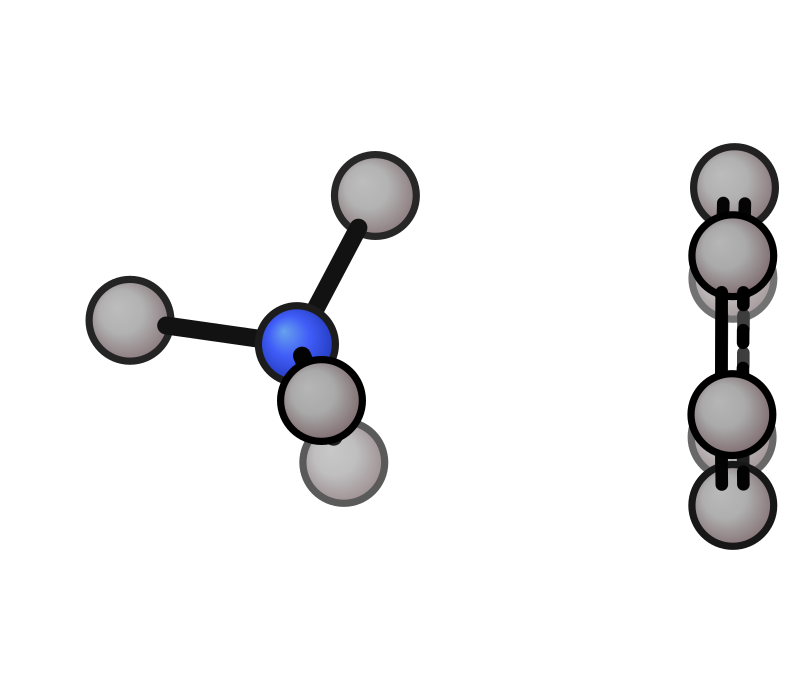

In [4]:
cands = rx.nci_candidates(Chem.AddHs(Chem.MolFromSmiles("C[N+](C)(C)C.c1ccccc1")), kinds=("CATPI", "CHPI"))
catpi = next(k for k in cands if k.startswith("CATPI"))
print("π contact:", catpi)
ens = rx.embed("C[N+](C)(C)C.c1ccccc1", contacts=cands[catpi], n=8).mc(preset="rapid").prune()
ring = [a.GetIdx() for a in ens.mol.GetAtoms() if a.GetIsAromatic()]
N = ens.mol.GetSubstructMatch(Chem.MolFromSmarts("[N+]"))[0]
import numpy as np

sep = np.mean(
    [
        float(
            np.linalg.norm(
                ens.mol.GetConformer(c).GetPositions()[N] - ens.mol.GetConformer(c).GetPositions()[ring].mean(0)
            )
        )
        for c in ens.ids
    ]
)
print(f"{len(ens)} conformers; N⁺···ring-centroid {sep:.2f} Å (cation-π)")
xyzrender.render(ens.lowest(1).dump(tempfile.mktemp(suffix=".xyz")), no_hy=True)

The halogen-bonded complex embeds at the right σ-hole distance and passes the gate — a clean, real contact.

rxembed | embed: 8 seeds (19 atoms, 2 fragments, 2 constraints)
rxembed | mc: +1 (openconf 'ensemble', pose-constrained around seeds; total 9)
rxembed | prune[rmsd]: 9 -> 6  (merged 3 near-duplicates; see .duplicates())


I···N realised: 3.6 Å  ( 6 confs, target 3.0-3.6 )
geometry.check: CLEAN ✓


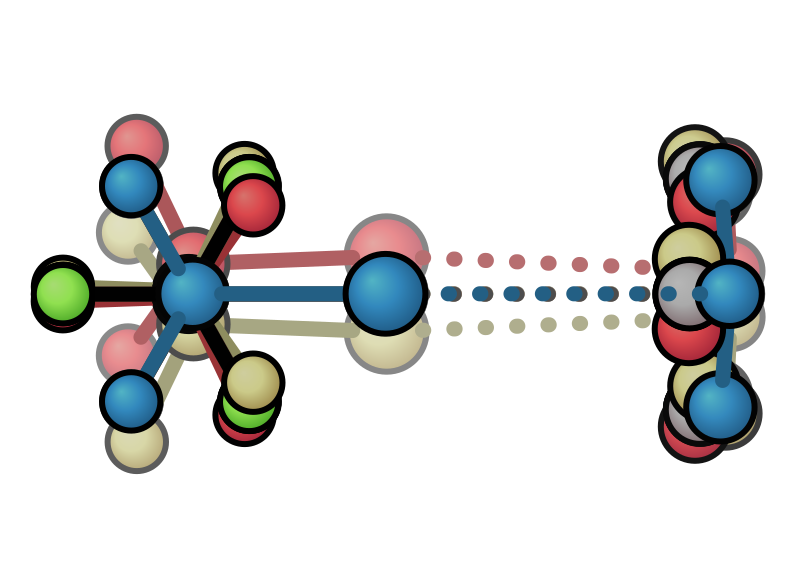

In [11]:
smi = "FC(F)(F)C(F)(F)I.c1ccncc1"
cands = rx.nci_candidates(Chem.AddHs(Chem.MolFromSmiles(smi)))
xb_contact = cands[next(k for k in cands if k.startswith("XB:"))]  # the I···N σ-hole, not halogen-π
xb = rx.embed(smi, contacts=xb_contact, n=8).mc(preset="ensemble").prune()
print("I···N realised:", round(xb.measure(("I", "n"))["mean"], 2), "Å  (", len(xb), "confs, target 3.0-3.6 )")
rep = rx.geometry.check(xb.mol, conf_id=xb.ids[0])
print("geometry.check:", "CLEAN ✓" if rep.ok() else f"FAIL ✗ {rep.violations[:6]}")
xyzrender.render(
    xyzrender.load(xb.dump(tempfile.mktemp(suffix=".xyz")), ensemble=True, ensemble_color="spectral", nci_detect=True),
    no_hy=True,
)

## A bifurcated grip — the Schreiner thiourea

`nci_modes` groups both thiourea N–H donors onto one carbonyl acceptor **automatically** — the bifurcated clamp. `binding_modes()` reports which contact patterns the search sampled.

In [13]:
schr = "FC(F)(F)c1cc(cc(c1)C(F)(F)F)NC(=S)Nc1cc(cc(c1)C(F)(F)F)C(F)(F)F.CC(C)=O"
print("modes:", list(rx.nci_modes(Chem.AddHs(Chem.MolFromSmiles(schr)))))
mode = next(iter(rx.nci_modes(Chem.AddHs(Chem.MolFromSmiles(schr))).values()))
ens = rx.embed(schr, contacts=mode, n=10).mc(preset="ensemble").prune()
print(f"{len(ens)} conformers; inter-fragment patterns sampled:")
for sig, n in ens.binding_modes().most_common()[:4]:
    print(f"   {n:3d}: {list(sig) or ['(none)']}")

rxembed | embed: 10 seeds (50 atoms, 2 fragments, 4 constraints)


modes: ['HB:H40,H39->O35']


rxembed | mc: +15 (openconf 'ensemble', pose-constrained around seeds; total 25)
rxembed | prune[rmsd]: 25 -> 24  (merged 1 near-duplicates; see .duplicates())


24 conformers; inter-fragment patterns sampled:
    24: ['hbond_bifurcated']


### The gate as an acceptance filter

This hindered bis(3,5-CF₃)phenyl thiourea is a good test of the gate: sterics twist the aryl–thiourea conjugation in some rotamers, and the gate **flags exactly those** — so it is a real acceptance test, not a rubber stamp. Filter the ensemble to the conformers that pass.

In [14]:
ens.minimize()
clean = [i for i in ens.ids if rx.geometry.check(ens.mol, conf_id=i).ok()]
print(
    f"{len(clean)}/{len(ens.ids)} conformers pass the gate "
    f"(the rest have a twisted aryl–thiourea — the gate catching real strain)"
)
rep = rx.geometry.check(ens.mol, conf_id=clean[0])  # a passing conformer is clean
print("geometry.check:", "CLEAN ✓" if rep.ok() else f"FAIL ✗ {rep.violations[:6]}")

6/24 conformers pass the gate (the rest have a twisted aryl–thiourea — the gate catching real strain)
geometry.check: CLEAN ✓


## Bias the seed, let energy decide — `mc(explore=True)`

The seeded contact is a bias, not truth. `explore=True` fires the search **twice** — grip preserved, grip released (structural holds kept) — and pools both, so a real energy (GFN-FF / g-xTB) chooses rather than trusting the seed. Here the pool is larger than the held-only search.

rxembed | embed: 8 seeds (50 atoms, 2 fragments, 4 constraints)
rxembed | mc: preset='rapid' on a constrained system under-samples (pose-mode is rotor-only); 'ensemble' (the default) is recommended for a constrained run
rxembed | mc: +5 (openconf 'rapid', pose-constrained around seeds; total 13)
rxembed | mc explore: +5 relaxed conformer(s) (NCI contacts released; 1 structural/encounter hold(s) kept; total 18)
rxembed | embed: 8 seeds (50 atoms, 2 fragments, 4 constraints)
rxembed | mc: preset='rapid' on a constrained system under-samples (pose-mode is rotor-only); 'ensemble' (the default) is recommended for a constrained run
rxembed | mc: +5 (openconf 'rapid', pose-constrained around seeds; total 13)


explore pool: 18 conformers   (held-only: 13)


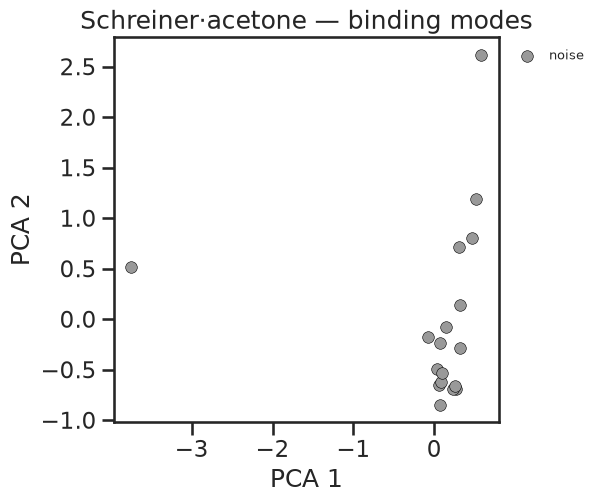

In [15]:
pool = rx.embed(schr, contacts=mode, n=8).mc(preset="rapid", explore=True)
held = rx.embed(schr, contacts=mode, n=8).mc(preset="rapid")
print(f"explore pool: {pool.n} conformers   (held-only: {held.n})")
pool.landscape("pca", color="cluster")
plt.title("Schreiner·acetone — binding modes")
plt.show()

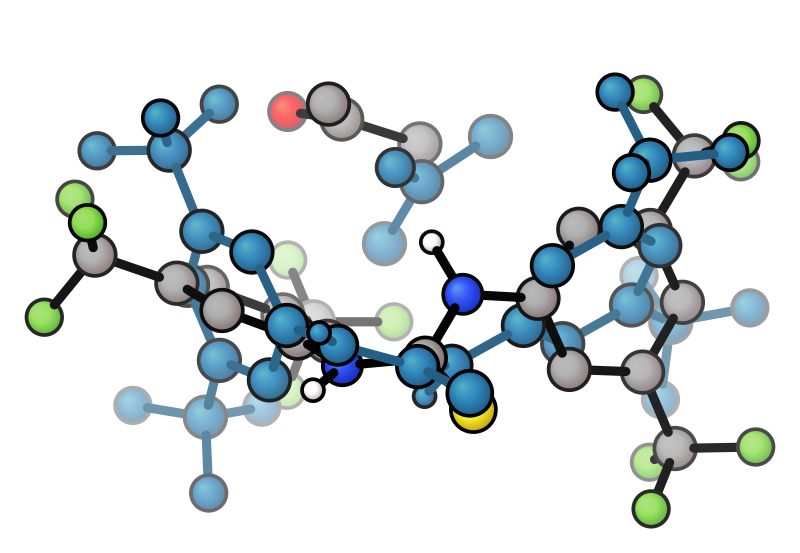

In [20]:
xyzrender.render(
    xyzrender.load(
        pool.lowest(2).dump(tempfile.mktemp(suffix=".xyz")), ensemble=True, ensemble_color="spectral", nci_detect=True
    ),
    no_hy=True,
)